# Image Classification

In [ ]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
from IPython.display import clear_output
from torch import nn, optim
from torchvision import transforms
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
%matplotlib inline

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## 1. Training a convolutional neural network for image classification

### Let's take a look at the CIFAR-10 dataset

**CIFAR-10** (Canadian Institute For Advanced Research) is a popular dataset for computer vision tasks, containing 60,000 color images measuring 32×32 pixels, divided into 10 classes:

- Airplane
- Automobile - Bird
- Cat
- Deer
- Dog
- Frog
- Horse
- Ship
- Truck

**Dataset structure:**
- Training sample: 50,000 images
- Test sample: 10,000 images

**Dataset features:**
- Small image size (32×32) allows for quick experimentation
- Diverse object classes
- Real photos with different lighting conditions and angles

Let's load the dataset in the same way we loaded MNIST in previous lessons, but taking into account the characteristics of color images.

In [ ]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261)),
    ]
)

cifar_train = torchvision.datasets.CIFAR10(
    root="./cifar", train=True, download=True, transform=transform
)
cifar_val = torchvision.datasets.CIFAR10(
    root="./cifar", train=False, download=True, transform=transform
)

train_dataloader = torch.utils.data.DataLoader(
    cifar_train, batch_size=32, shuffle=True, num_workers=2
)
val_dataloader = torch.utils.data.DataLoader(
    cifar_val, batch_size=32, shuffle=False, num_workers=2
)

100%|██████████| 170M/170M [00:13<00:00, 12.4MB/s]


In [ ]:
def matplotlib_imshow(img, one_channel=False):
    if one_channel:
        img = img.mean(dim=0)
    img = img / 2 + 0.5
    npimg = img.numpy()
    if one_channel:
        plt.imshow(npimg, cmap="Greys")
    else:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))

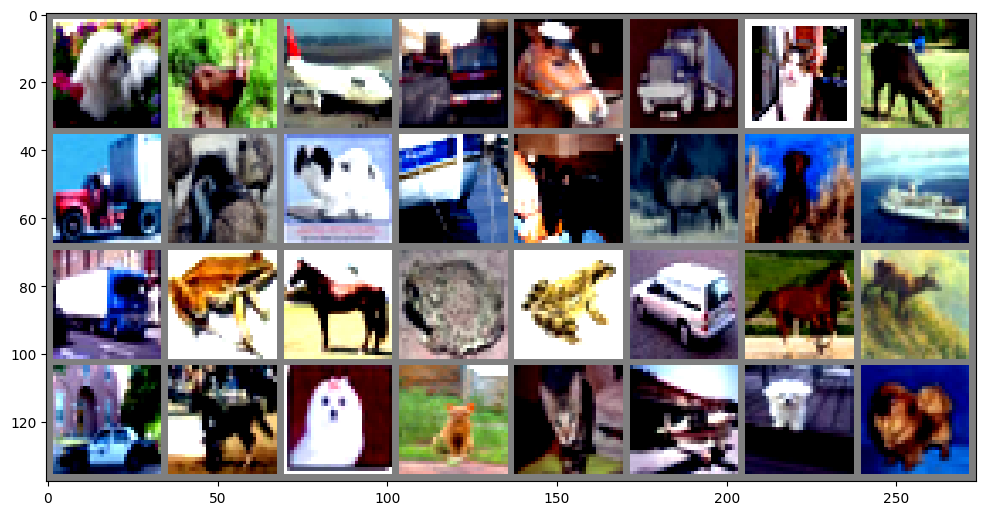

In [ ]:
images, labels = next(iter(train_dataloader))

plt.figure(figsize=(12, 12))
# create grid of images
img_grid = torchvision.utils.make_grid(images)
# show images
matplotlib_imshow(img_grid, one_channel=False)

In [ ]:
def plot_history(train_history, val_history, title="loss"):
    plt.figure()
    plt.title(title)
    plt.plot(train_history, label="train", zorder=1)

    points = np.array(val_history)
    steps = list(
        range(0, len(train_history) + 1, int(len(train_history) / len(val_history)))
    )[1:]

    plt.scatter(
        steps, val_history, marker="+", s=180, c="orange", label="val", zorder=2
    )
    plt.xlabel("train steps")

    plt.legend(loc="best")
    plt.grid()

    plt.show()

### VGG
Let's build the following architecture from 1 VGG block:

1) VGG block with 16 channels:
* Convolution layer with 16 output channels and a 3x3 kernel, padding, and ReLU nonlinearity
* Convolution layer with 16 output channels and a 3x3 kernel, padding, and ReLU nonlinearity
* Max pooling with a 2x2 kernel and a stride of 2

2) Fully connected layer with 128 outputs and ReLU nonlinearity

3) Fully connected layer with 10 outputs

In [ ]:
net = nn.Sequential(
    nn.Conv2d(3, 16, 3, padding=1),
    nn.ReLU(),
    nn.Conv2d(16, 16, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
)
net(torch.rand((1, 3, 32, 32))).size()  # 16 * 16 * 16

torch.Size([1, 16, 16, 16])

In [ ]:
class ModelBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),  # .reshape(batch, -1)
            nn.LazyLinear(128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        if len(x.size()) < 4:
            return self.net(x.unsqueeze(0)).squeeze(0)
        return self.net(x)

In [ ]:
def train(model, criterion, optimizer, train_dataloader, val_dataloader, n_epochs=5):
    train_loss_log, train_acc_log, val_loss_log, val_acc_log = [], [], [], []

    for epoch in range(n_epochs):
        train_epoch_loss, train_epoch_true_hits = torch.empty(0), torch.empty(0)
        model.train()
        for imgs, labels in tqdm(
            train_dataloader, desc=f"Training, epoch {epoch}", leave=False
        ):
            imgs, labels = imgs.to(device), labels.to(device)

            y_pred = model(imgs)
            loss = criterion(y_pred, labels)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            # log loss for the current epoch and the whole training history
            train_epoch_loss = torch.cat(
                (train_epoch_loss, loss.cpu().unsqueeze(0) / labels.cpu().size(0))
            )
            train_loss_log.append(loss.cpu().data / labels.cpu().size(0))

            # log accuracy for the current epoch and the whole training history
            pred_classes = torch.argmax(y_pred.cpu(), dim=-1)
            train_epoch_true_hits = torch.cat(
                (
                    train_epoch_true_hits,
                    (pred_classes == labels.cpu()).sum().unsqueeze(0),
                )
            )
            train_acc_log.append(
                (pred_classes == labels.cpu()).sum() / labels.cpu().shape[0]
            )

        val_epoch_loss, val_epoch_true_hits = torch.empty(0), torch.empty(0)
        model.eval()
        with torch.no_grad():
            for imgs, labels in tqdm(
                val_dataloader, desc=f"Validating, epoch {epoch}", leave=False
            ):
                imgs, labels = imgs.to(device), labels.to(device)

                y_pred = model(imgs)
                loss = criterion(y_pred, labels)
                val_epoch_loss = torch.cat(
                    (val_epoch_loss, loss.cpu().unsqueeze(0) / labels.cpu().size(0))
                )

                pred_classes = torch.argmax(y_pred.cpu(), dim=-1)
                val_epoch_true_hits = torch.cat(
                    (
                        val_epoch_true_hits,
                        (pred_classes == labels.cpu()).sum().unsqueeze(0),
                    )
                )

        val_loss_log.append(val_epoch_loss.mean())
        val_acc_log.append(
            val_epoch_true_hits.sum()
            / val_epoch_true_hits.size(0)
            / val_dataloader.batch_size
        )
        clear_output()
        plot_history(train_loss_log, val_loss_log, "loss")
        plot_history(train_acc_log, val_acc_log, "accuracy")

        print("Train loss:", train_epoch_loss.mean().item())
        print(
            "Train acc:",
            (
                train_epoch_true_hits.sum()
                / train_epoch_true_hits.size(0)
                / train_dataloader.batch_size
            ).item(),
        )
        print("Val loss:", val_epoch_loss.mean().item())
        print(
            "Val acc:",
            (
                val_epoch_true_hits.sum()
                / val_epoch_true_hits.size(0)
                / val_dataloader.batch_size
            ).item(),
        )

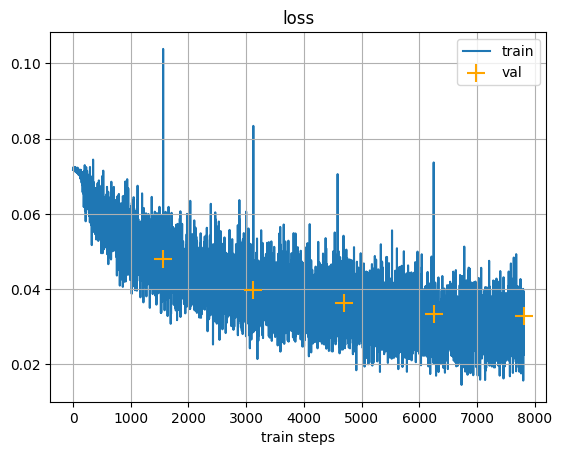

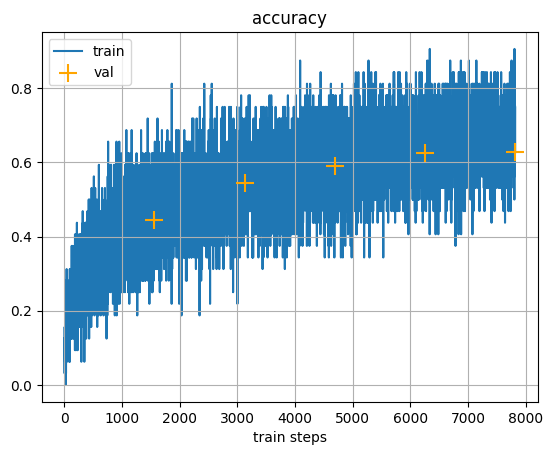

Train loss: 0.029767705127596855
Train acc: 0.6638675332069397
Val loss: 0.03297773748636246
Val acc: 0.6277955174446106


In [ ]:
model_baseline = ModelBaseline().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_baseline.parameters(), lr=0.001, momentum=0.9)

train(model_baseline, criterion, optimizer, train_dataloader, val_dataloader)

### Let's look at how filters work

In [ ]:
# Launch these cells when working from Collab
!wget https://raw.githubusercontent.com/hse-ds/iad-deep-learning/master/2022/seminars/sem03/filter_viz.py

import sys

from google.colab import drive

drive.mount("/content/gdrive")
sys.path.append("/content/gdrive/My Drive")

--2025-11-29 10:15:00--  https://raw.githubusercontent.com/hse-ds/iad-deep-learning/master/2022/seminars/sem03/filter_viz.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3188 (3.1K) [text/plain]
Saving to: ‘filter_viz.py’

filter_viz.py       100%[===================>]   3.11K  --.-KB/s    in 0s      

2025-11-29 10:15:01 (58.8 MB/s) - ‘filter_viz.py’ saved [3188/3188]

Mounted at /content/gdrive


In [ ]:
from filter_viz import plot_filters

In [ ]:
model_baseline.cpu()

ModelBaseline(
  (net): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Flatten(start_dim=1, end_dim=-1)
    (6): Linear(in_features=4096, out_features=128, bias=True)
    (7): ReLU()
    (8): Linear(in_features=128, out_features=10, bias=True)
  )
)

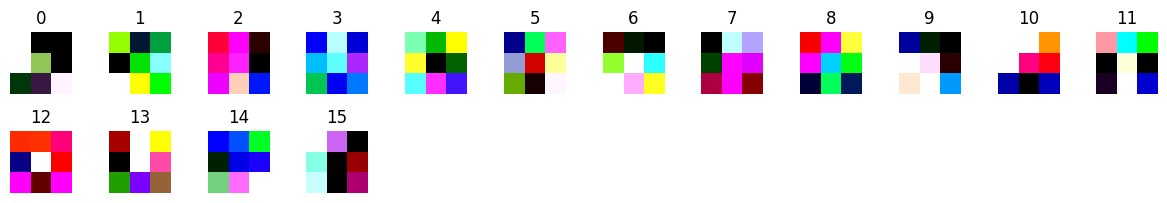

In [ ]:
plot_filters(model_baseline.net[0], single_channel=False)

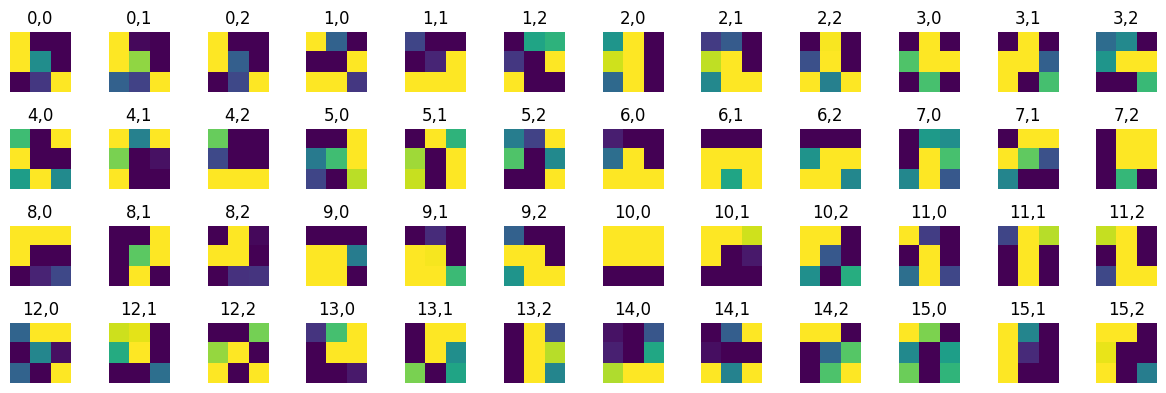

In [ ]:
plot_filters(model_baseline.net[0], single_channel=True)

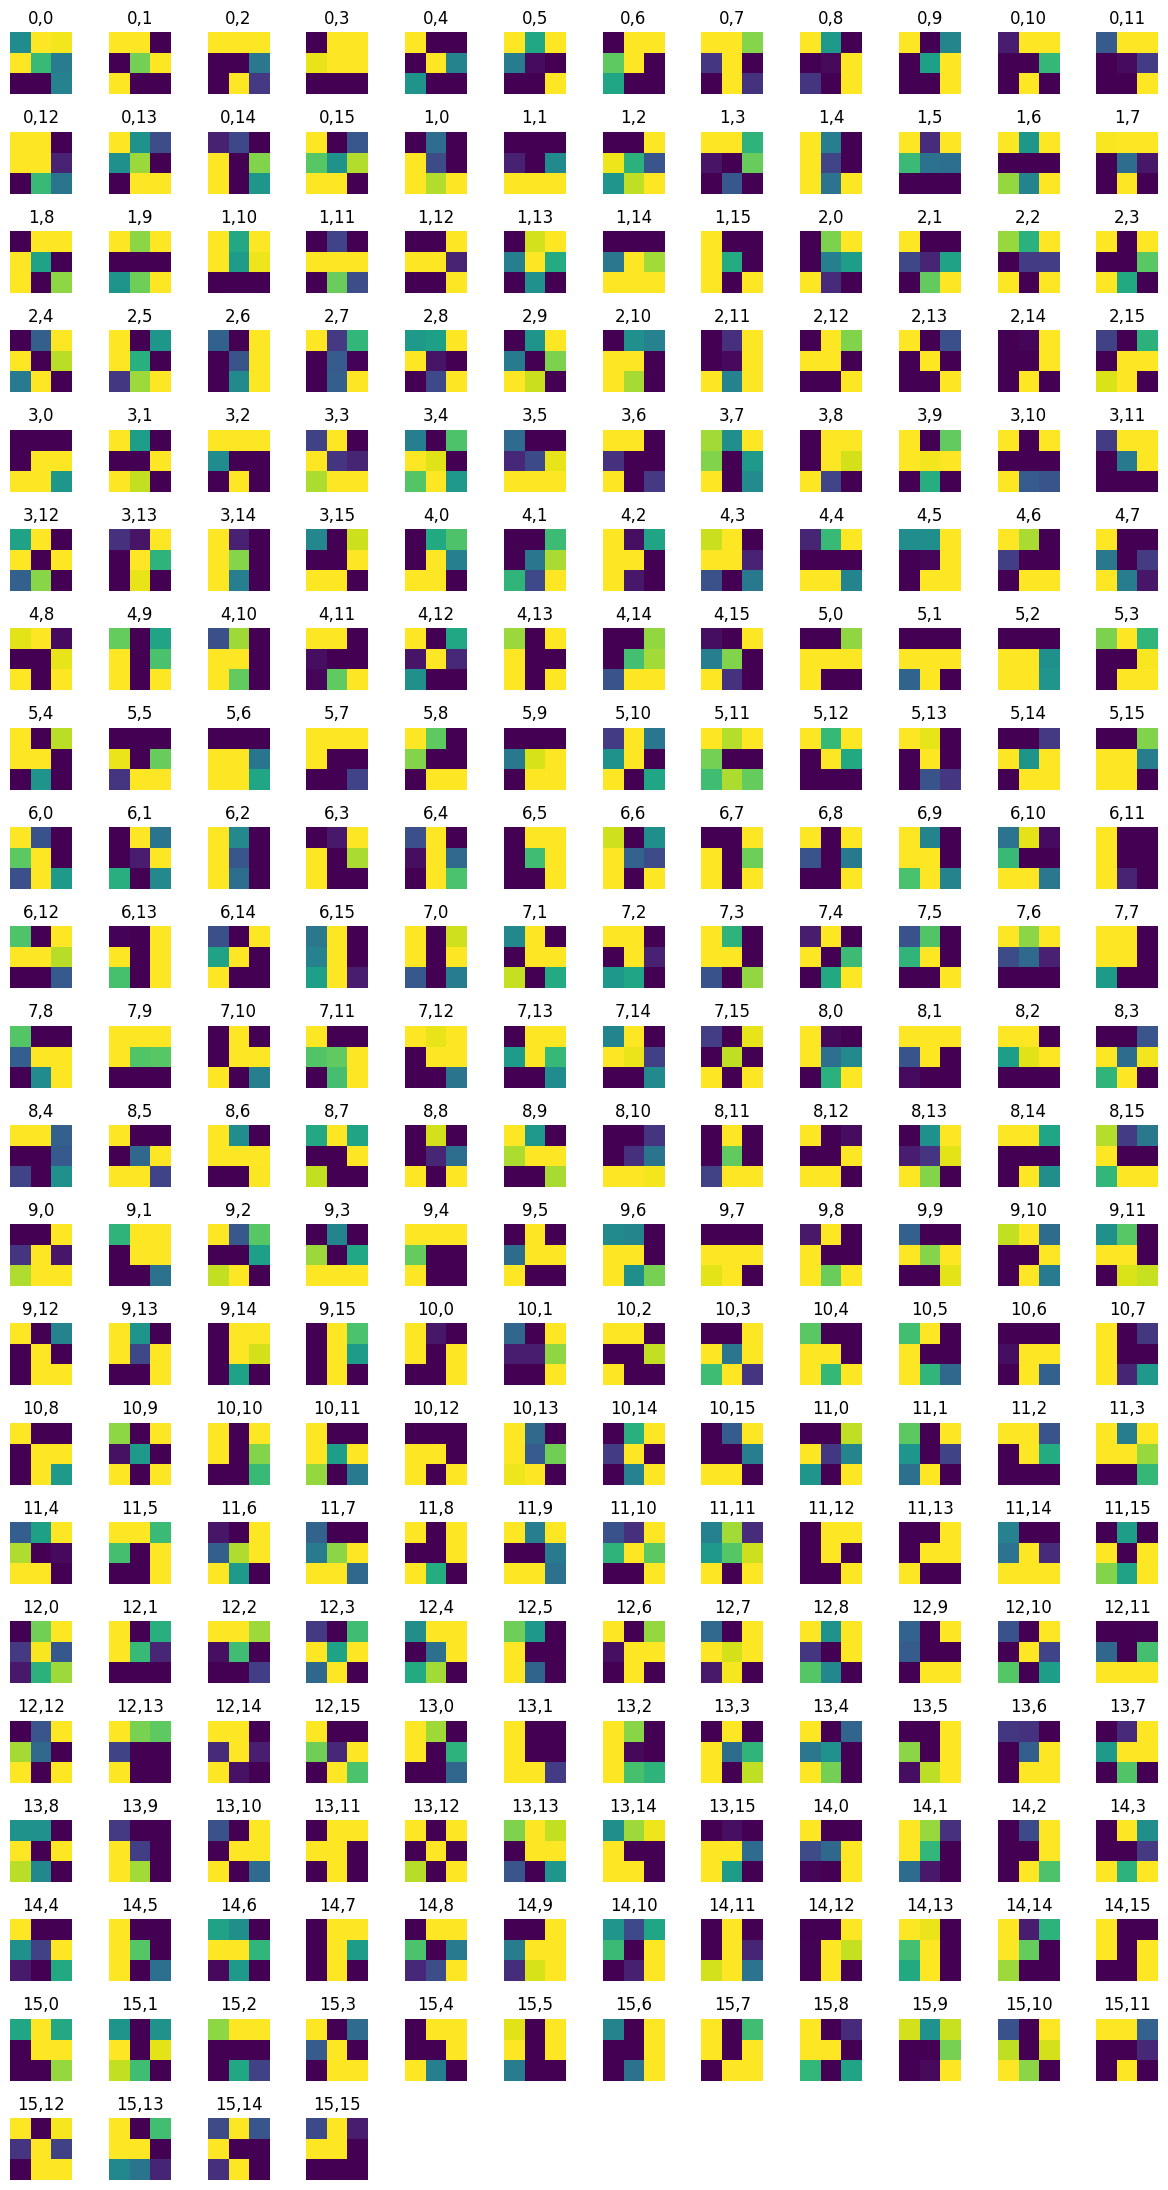

In [ ]:
plot_filters(model_baseline.net[2], single_channel=True)

### How different activation functions work

Let's experiment with neural network activation functions. Let's replace ReLU with LeakyReLU, ELU, or SELU and try to understand how the replacement affects the quality and speed of convergence.

You can read about different activation functions [here](https://ml-explained.com/blog/activation-functions-explained) and in the [PyTorch documentation](https://pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity).

In [ ]:
np.random.seed(42)

In [ ]:
np.random.random()

0.7319939418114051

In [ ]:
class ModelBaseline(nn.Module):
    def __init__(self, activation=nn.ReLU):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            activation(),
            nn.Conv2d(16, 16, 3, padding=1),
            activation(),
            nn.MaxPool2d(2),
            nn.Flatten(),  # .reshape(batch, -1)
            nn.LazyLinear(128),
            activation(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        if len(x.size()) < 4:
            return self.net(x.unsqueeze(0)).squeeze(0)
        return self.net(x)


model_baseline2 = ModelBaseline(activation=nn.LeakyReLU).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_baseline2.parameters(), lr=0.001, momentum=0.9)

train(model_baseline2, criterion, optimizer, train_dataloader, val_dataloader)

Training, epoch 0:   0%|          | 0/1563 [00:00<?, ?it/s]

KeyboardInterrupt: 

LeakyReLU works a little better)

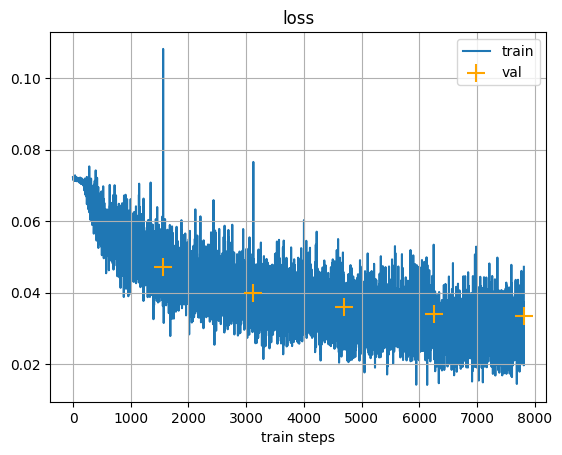

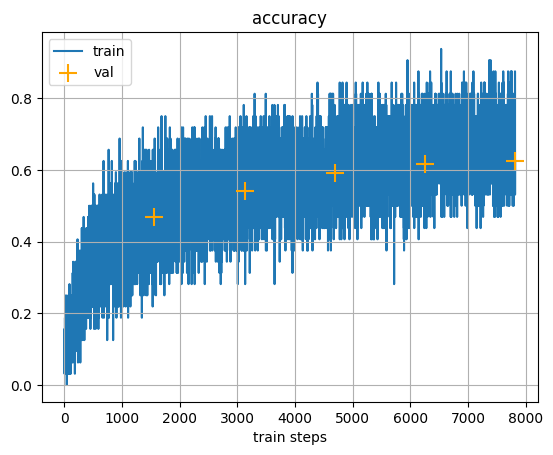

Train loss: 0.02926941215991974
Train acc: 0.6728246808052063
Val loss: 0.03343653306365013
Val acc: 0.6245008111000061


In [ ]:
model_baseline2 = ModelBaseline(activation=nn.GELU).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_baseline2.parameters(), lr=0.001, momentum=0.9)

train(model_baseline2, criterion, optimizer, train_dataloader, val_dataloader)

## 2. Augmentations

**Data augmentation** is a technique for artificially increasing the size of the training sample by applying various transformations to the original images.

**The main goals of augmentations:**
1. **Increasing diversity** - the model sees more data variations
2. **Regularization** - preventing overfitting
3. **Increasing robustness** - the model becomes more resistant to various distortions

### Types of augmentations:

**Geometric transformations:**
- Rotations and reflections
- Scaling and cropping
- Perspective distortions

**Color transformations:**
- Changing brightness and contrast
- Gamma correction
- Color distortions

**Other transformations:**
- Adding noise
- Blurring
- Elastic deformations

In PyTorch, augmentations are implemented through the `torchvision.transforms` module. Using the Compose function, you can combine several image transformations and then apply them when reading the dataset. The full list of augmentations is available [here](https://pytorch.org/vision/stable/transforms.html). Study it and experiment with different image transformations.

The `albumentations` library is a powerful and effective tool for image augmentations.

In [ ]:
import PIL

transform = transforms.Compose(
    [
        transforms.ColorJitter(hue=0.05, saturation=0.05),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261)),
    ]
)

base_transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261)),
    ]
)

cifar_train = torchvision.datasets.CIFAR10(
    root="./cifar", train=True, download=True, transform=transform
)
cifar_val = torchvision.datasets.CIFAR10(
    root="./cifar", train=False, download=True, transform=base_transform
)

train_dataloader = torch.utils.data.DataLoader(
    cifar_train, batch_size=32, shuffle=True, num_workers=4
)
val_dataloader = torch.utils.data.DataLoader(
    cifar_val, batch_size=32, shuffle=False, num_workers=4
)

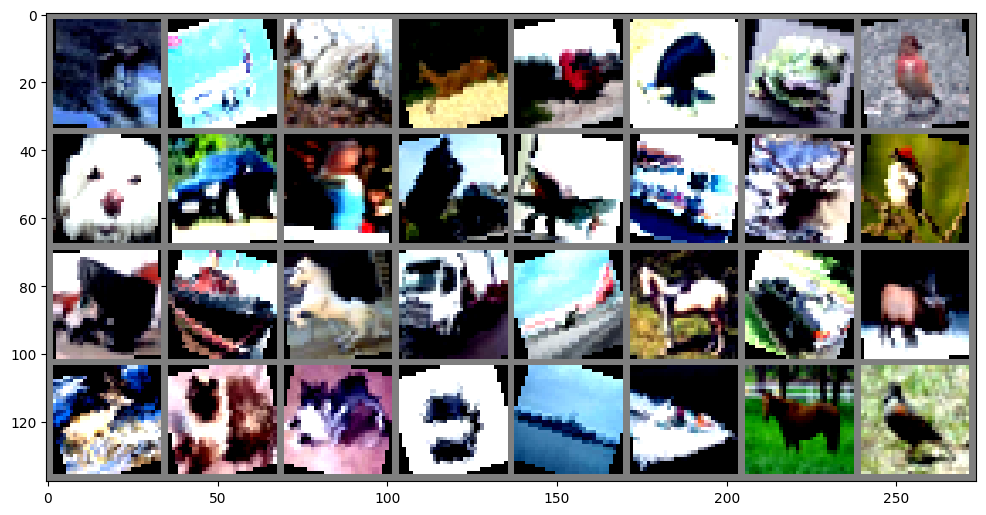

In [ ]:
images, labels = next(iter(train_dataloader))

plt.figure(figsize=(12, 12))
# create grid of images
img_grid = torchvision.utils.make_grid(images)
# show images
matplotlib_imshow(img_grid, one_channel=False)

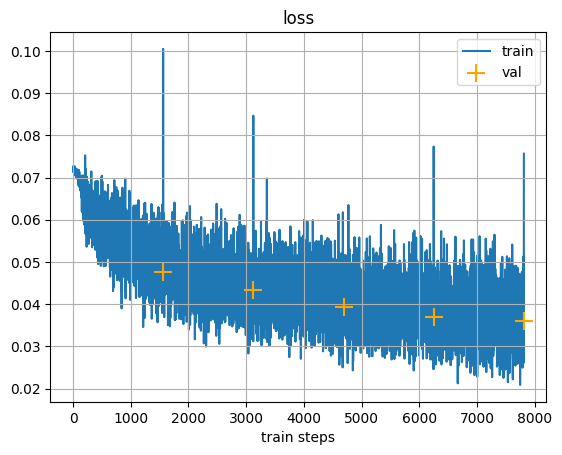

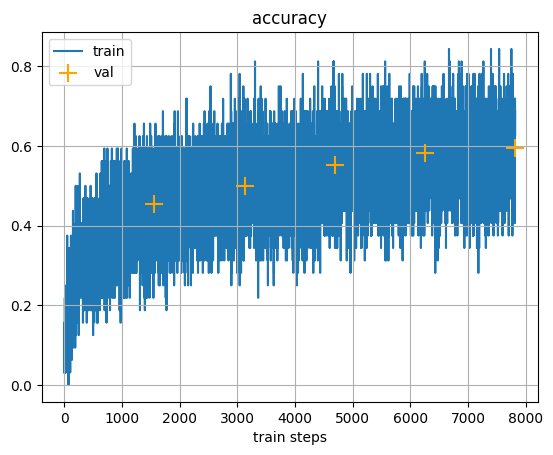

Train loss: 0.03724221885204315
Train acc: 0.5770753622055054
Val loss: 0.03597361966967583
Val acc: 0.5938498377799988


In [ ]:
model_baseline = ModelBaseline().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_baseline.parameters(), lr=0.001, momentum=0.9)

train(model_baseline, criterion, optimizer, train_dataloader, val_dataloader)

Let's train a new network with three VGG blocks and add batch normalization and dropout to it.

In [ ]:
model = nn.Sequential(
    nn.Conv2d(3, 16, 3, padding=1),
    nn.BatchNorm2d(16),
    nn.ReLU(),
    nn.Conv2d(16, 16, 3, padding=1),
    nn.BatchNorm2d(16),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),
    nn.Dropout(0.2),
    nn.Conv2d(16, 32, 3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.Conv2d(32, 32, 3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),
    nn.Dropout(0.2),
    nn.Conv2d(32, 64, 3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.Conv2d(64, 64, 3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),
    nn.Dropout(0.2),
    nn.Flatten(),
    nn.Linear(64 * 4 * 4, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 10),
)

In [ ]:
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

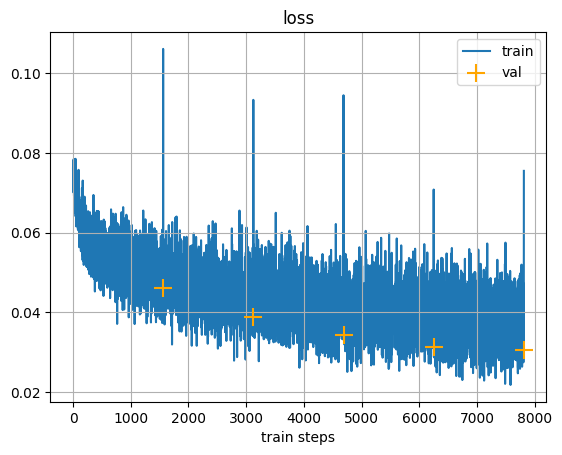

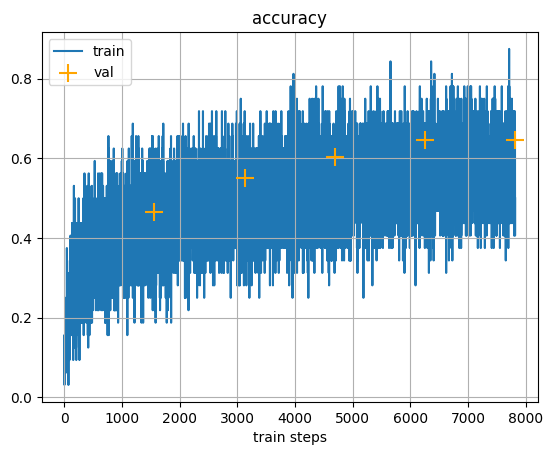

Train loss: 0.03764567896723747
Train acc: 0.5749959945678711
Val loss: 0.030461324378848076
Val acc: 0.6461661458015442


In [ ]:
train(model, criterion, optimizer, train_dataloader, val_dataloader)

## PyTorch VS PyTorch Lightning

[**PyTorch Lightning**](https://pytorch-lighting.readthedocs.io/en/stable/) is a framework that simplifies the following tasks:
- writing training cycles
- writing datasets
- using GPU/TPU/IPU/HPU, etc.
- converting models to ONNX format
- and much more

The framework allows users to configure parameters and conduct experiments without having to deal with “routine” and “technical” details. Let's compare the code in **PyTorch** with and without **Lightning** using the example of a simple neural network on the FashionMNIST dataset.

In [ ]:
!pip install lightning

from collections import defaultdict, namedtuple

import pytorch_lightning as pl
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchmetrics.functional import accuracy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.0/846.0 kB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.5/849.5 kB 59.9 MB/s eta 0:00:00


### Data preparation (common to both approaches)

Define DataLoader for training and validation samples

In [ ]:
fashion_mnist_train = torchvision.datasets.FashionMNIST(
    "./data", download=True, transform=transforms.Compose([transforms.ToTensor()])
)
train_dataloader = DataLoader(
    fashion_mnist_train, batch_size=128, shuffle=True, num_workers=4
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 193kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.52MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 8.61MB/s]


In [ ]:
fashion_mnist_val = torchvision.datasets.FashionMNIST(
    "./data",
    train=False,
    download=True,
    transform=transforms.Compose([transforms.ToTensor()]),
)
val_dataloader = DataLoader(fashion_mnist_val, batch_size=128, num_workers=4)

In [ ]:
idx_to_label = defaultdict(
    None,
    {
        0: "T-shirt/Top",
        1: "Trouser",
        2: "Pullover",
        3: "Dress",
        4: "Coat",
        5: "Sandal",
        6: "Shirt",
        7: "Sneaker",
        8: "Bag",
        9: "Ankle Boot",
    },
)

Let's take a look at a few samples

Ankle Boot


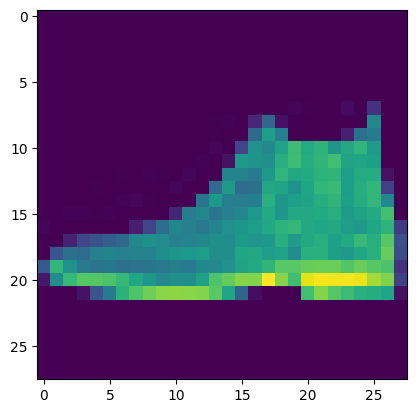

Trouser


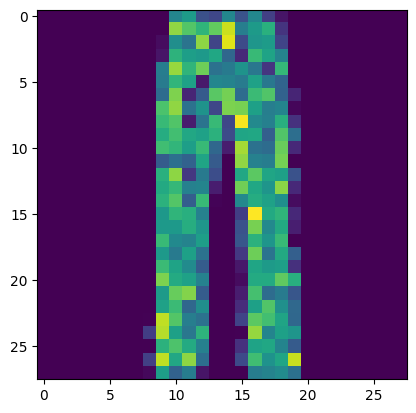

Bag


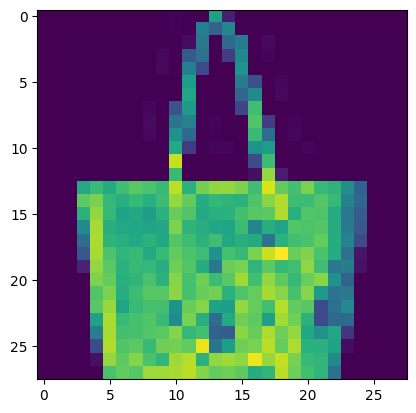

In [ ]:
for num, batch in enumerate(val_dataloader):
    images, class_nums = batch
    print(idx_to_label[int(class_nums[0])])
    plt.imshow(images[0].squeeze())
    plt.show()

    if num == 2:
        break

### Model creation (common to both approaches)



Let's create a model class with the following configuration:

1. Conv(1->32, kernel=3, padding=1), BatchNorm, ReLU, MaxPool(2)
2. Conv(32->64, kernel=3, padding=1), BatchNorm, ReLU, MaxPool(2)
3. Flatten
4. Linear, ReLU
5. Linear

In [ ]:
class SimpleNet(torch.nn.Module):
    def __init__(self, dropout=0.4):
        super().__init__()

        self.conv1 = torch.nn.Sequential(
            torch.nn.Conv2d(1, 32, kernel_size=3, padding=1),
            torch.nn.BatchNorm2d(32),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2),
        )

        self.conv2 = torch.nn.Sequential(
            torch.nn.Conv2d(32, 64, kernel_size=3, padding=1),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2),
        )

        self.classifier = torch.nn.Sequential(
            torch.nn.Flatten(),  # 64 * 7 * 7
            torch.nn.Linear(64 * 7 * 7, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, 10),
        )

        self.loss_func = torch.nn.CrossEntropyLoss()
        self.targets = torch.Tensor()
        self.preds = torch.Tensor()

    def _forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.classifier(x)
        return x

    def forward(self, images, target=None):
        # images ~ (batch size, num channels, height, width)
        # target ~ (batch size)
        # output ~ (batch size, num classes)
        output = self._forward(images)

        # get accuracy score and save it to self.accuracy
        if target is not None:
            loss = self.loss_func(output, target)

            self.targets = torch.cat((self.targets, target.cpu()), 0)
            pred = torch.argmax(output, dim=-1)
            self.preds = torch.cat((self.preds, pred.cpu()), 0)
            self.accuracy = accuracy(
                self.preds.long(),
                self.targets.long(),
                task="multiclass",
                num_classes=10,
            )

        return loss if target is not None else output

    def get_accuracy(self, reset=False):
        if reset:
            self.targets = torch.Tensor()
            self.preds = torch.Tensor()
        return self.accuracy

### Hyperparameters

In [ ]:
LossInfo = namedtuple(
    "LossInfo", ["full_train_losses", "train_epoch_losses", "eval_epoch_losses"]
)
EPOCHS = 3
LR = 0.001

### Training cycles (PyTorch)

Let's declare the functions `train_epoch`, `validate`, and `fit`.
As a reminder, the simplified structure looks like this:
```
def train_epoch():
    for batch in train_loader:
        train_model_on_batch()
def validate():
    for batch in val_loader:
        validate_model_on_batch()
def fit():
    for epoch in range(1, num_epochs):
        train_epoch()
        validate()
```


However, it looks quite bulky in the code...

In [ ]:
def train_epoch(
    model,
    data_loader,
    optimizer,
    return_losses=False,
    device="cuda:0",
):
    model = model.train()
    total_loss = 0
    num_batches = 0
    all_losses = []
    with tqdm(total=len(data_loader), file=sys.stdout) as prbar:
        for batch in data_loader:
            # move Batch to GPU
            batch = [x.to(device=device) for x in batch]
            loss = model(*batch)
            # update weights
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            # update description for tqdm
            accuracy = model.get_accuracy()
            prbar.set_description(
                f"Loss: {round(loss.item(), 4)} "
                f"Accuracy: {round(accuracy.item() * 100, 4)}"
            )
            prbar.update(1)
            total_loss += loss.item()
            num_batches += 1
            all_losses.append(loss.detach().item())
    acc = model.get_accuracy(reset=True)
    metrics = {"loss": total_loss / num_batches, "accuracy": acc}
    if return_losses:
        return metrics, all_losses
    else:
        return metrics


def validate(model, data_loader, device="cuda:0"):
    model = model.eval()
    total_loss = 0
    num_batches = 0
    with tqdm(total=len(data_loader), file=sys.stdout) as prbar:
        for batch in data_loader:
            batch = [x.to(device=device) for x in batch]
            loss = model(*batch)
            accuracy = model.get_accuracy()
            prbar.set_description(
                f"Loss: {round(loss.item(), 4)} "
                f"Accuracy: {round(accuracy.item() * 100, 4)}"
            )
            prbar.update(1)
            total_loss += loss.item()
            num_batches += 1
    acc = model.get_accuracy(reset=True)
    metrics = {"loss": total_loss / num_batches, "accuracy": acc}
    return metrics

In [ ]:
def fit(
    model,
    epochs,
    train_data_loader,
    validation_data_loader,
    optimizer,
    scheduler=None,
    device="cuda:0",
):
    all_train_losses = []
    epoch_train_losses = []
    epoch_eval_losses = []
    for epoch in range(epochs):
        # construct iterators
        train_iterator = iter(train_data_loader)
        validation_iterator = iter(validation_data_loader)
        # train step
        print(f"Train Epoch: {epoch}")
        train_metrics, one_epoch_train_losses = train_epoch(
            model=model,
            data_loader=train_iterator,
            optimizer=optimizer,
            return_losses=True,
            device=device,
        )
        # save train losses
        all_train_losses.extend(one_epoch_train_losses)
        epoch_train_losses.append(train_metrics["loss"])
        # eval step
        print(f"Validation Epoch: {epoch}")
        with torch.no_grad():
            validation_metrics = validate(
                model=model, data_loader=validation_iterator, device=device
            )
        # save eval losses
        epoch_eval_losses.append(validation_metrics["loss"])
        # scheduler step
        if scheduler:
            scheduler.step()
    return LossInfo(all_train_losses, epoch_train_losses, epoch_eval_losses)

Let's train the model

In [ ]:
model = SimpleNet().to(device)
_ = fit(
    model=model,
    epochs=EPOCHS,  # approximately one minute on the GPU in the collab
    train_data_loader=train_dataloader,
    validation_data_loader=val_dataloader,
    optimizer=torch.optim.SGD(model.parameters(), lr=LR),
    device=device,
)

Train Epoch: 0


  0%|          | 0/469 [00:00<?, ?it/s]

Validation Epoch: 0


  0%|          | 0/79 [00:00<?, ?it/s]

Train Epoch: 1


...

  0%|          | 0/79 [00:00<?, ?it/s]

Train Epoch: 2


  0%|          | 0/469 [00:00<?, ?it/s]

Validation Epoch: 2


  0%|          | 0/79 [00:00<?, ?it/s]

### Training cycles (Lightning)

The structure here will be slightly different.

1) A single class is created, inherited from `LightningModule`. It specifies the model configuration and describes the training and validation steps.

2) An object of the `Trainer` class is created with parameters (e.g., GPU number, number of epochs, degree of clipping, etc.). [doc](https://pytorch-lighting.readthedocs.io/en/stable/api/pytorch_lightning.trainer.trainer.Trainer.html?highlight=trainer#pytorch_lightning.trainer.trainer.Trainer)

3) `trainer.fit(model, train_loader, val_loader)` is called.


```
class MyModule(pl.LightningModule):
    def init():
        init_model()
    def forward():
        forward_model()
    def training_step():
        make_1_training_step()
    def validation_step():
        make_1_validation_step()

trainer = pl.Trainer(gpus=1, max_epochs=10)
trainer.fit(model, train_loader, val_loader)
```
Since we already have the `SimpleNet` model, we don't need to make many changes.

In [ ]:
# 1 step. Create a LightningModule


class SimpleModule(pl.LightningModule):
    def __init__(self, model, learning_rate):
        super().__init__()
        self.model = model
        self.learning_rate = learning_rate

    def forward(self, x):
        result = self.model(x)
        return result

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        return optimizer

    def training_step(self, train_batch, batch_idx):
        images, target = train_batch
        loss = self.model(images, target)
        self.log(
            "train_loss", loss, prog_bar=True
        )  # saves logs to a folder, but you can easily add wandb
        return loss

    def validation_step(self, val_batch, batch_idx):
        images, target = val_batch
        loss = self.model(images, target)
        self.log("val_loss", loss, prog_bar=True)

In [ ]:
# 2 step. Config a model


model = SimpleNet().to(device)
module = SimpleModule(model, learning_rate=LR)

# 3 step. Create Trainer and train
trainer = pl.Trainer(accelerator="gpu", max_epochs=EPOCHS)
trainer.fit(module, train_dataloader, val_dataloader)

INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type      ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ SimpleNet │  421 K │ train │     0 │
└───┴───────┴───────────┴────────┴───────┴───────┘

Trainable params: 421 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 421 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 17                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.


Note how similar the behavior of `trainer.fit()` is to the `fit()` function we wrote earlier.


Also note that on Lightning, we:
1.   Did not describe the training cycle in terms of epochs or batches
2.   Did not risk forgetting zero_grad, .backward()
3.   Did not transfer either the model or the data to the GPU
4.   Got all kinds of cool stuff like auto_lr_find
5.   Retained the ability to use many **PyTorch** subtleties such as [schedulers](https://pytorch-lightning.readthedocs.io/en/stable/common/optimization.html), logging via [wandb](https://docs.wandb.ai/guides/integrations/lightning), and so on

In [ ]:
!wget https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip
!unzip -qq kagglecatsanddogs_5340.zip
!rm -rf PetImages/Cat/666.jpg PetImages/Dog/11702.jpg readme\[1\].txt CDLA-Permissive-2.0.pdf

--2025-11-29 11:15:29--  https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip
Resolving download.microsoft.com (download.microsoft.com)... 104.119.104.215, 2600:1413:b000:79b::317f, 2600:1413:b000:792::317f
Connecting to download.microsoft.com (download.microsoft.com)|104.119.104.215|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 824887076 (787M) [application/octet-stream]
Saving to: ‘kagglecatsanddogs_5340.zip’

kagglecatsanddogs_5 100%[===================>] 786.67M  45.9MB/s    in 11s     

2025-11-29 11:15:40 (74.2 MB/s) - ‘kagglecatsanddogs_5340.zip’ saved [824887076/824887076]



In [ ]:
dataset = ImageFolder(
    "./PetImages",
    transform=Compose(
        [
            Resize((224, 224)),
            ToTensor(),
            Normalize((0.5, 0.5, 0.5), (1, 1, 1)),
        ]
    ),
)
train_set, val_set = torch.utils.data.random_split(
    dataset, [int(0.8 * len(dataset)), len(dataset) - int(0.8 * len(dataset))]
)

train_dataloader = torch.utils.data.DataLoader(train_set, batch_size=256, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(val_set, batch_size=256, shuffle=False)

NameError: name 'ImageFolder' is not defined

Let's see what the pictures look like.

In [ ]:
file = np.random.choice(glob.glob("./PetImages/*/*.jpg"))
plt.axis("off")
plt.imshow(plt.imread(file));

## Fine-tuning

Cats and dogs are great, of course, but training a model that will work well on this dataset can take a very long time...

However, the images we will look at today are very similar to those from the huge ImageNet dataset. The task we will consider today is called Transfer Learning. We are indeed transferring knowledge—from a network that works well on one dataset (ImageNet) to other data (the Cats vs Dogs dataset).

#### Let's load the already trained network

The `torchvision` library not only implements a large number of models (all kinds of ResNets, Inception, VGG, AlexNet, DenseNet, ResNext, WideResNet, MobileNet...), but also loads the training checkpoints of these models on ImageNet. However, for the Cats vs Dogs dataset, such a thing is a luxury...

In [ ]:
!pip install pytorch_lightning torchmetrics torchvision

In [ ]:
import pytorch_lightning as pl
from torchmetrics.functional import accuracy
from torchvision.models import resnet18

In [ ]:
model = resnet18(pretrained=True)
model

In transfer learning, we replace the last layer of the neural network with a linear layer with two outputs, and “freeze” the weights of the other layers.

In [ ]:
class CatsVSDogsResnet(pl.LightningModule):
    def __init__(self, pretrained: bool = False) -> None:
        super().__init__()
        self.pretrained = pretrained

        if pretrained:
            # <YOUR CODE HERE>
            self.model = resnet18(pretrained=True)
            self.model.fc = nn.Identity()
            self.classifier = nn.Linear(512, 2)
            self.optimizer = torch.optim.Adam(self.classifier.parameters())
        else:
            # <YOUR CODE HERE>
            self.model = resnet18(pretrained=False)
            self.model.fc = nn.Linear(self.model.fc.in_features, 2)
            self.optimizer = torch.optim.Adam(self.model.parameters())

        self.loss = nn.CrossEntropyLoss()

    def forward(self, x) -> torch.Tensor:
        if self.pretrained:
            # <YOUR CODE HERE>
            with torch.no_grad():
                features = self.model(x)
            preds = self.classifier(features)
        else:
            # <YOUR CODE HERE>
            preds = self.model(x)
        return preds

    def configure_optimizers(self):
        return self.optimizer

    def training_step(self, train_batch, batch_idx) -> torch.Tensor:
        images, target = train_batch
        preds = self.forward(images)
        loss = self.loss(preds, target)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, val_batch, batch_idx) -> None:
        images, target = val_batch
        preds = self.forward(images)
        loss = self.loss(preds, target)
        acc = accuracy(torch.argmax(preds, dim=-1).long(), target.long(), task="binary")
        self.log("val_loss", loss, prog_bar=True)
        self.log("accuracy", acc, prog_bar=True)

Let's start transfer learning!

In [ ]:
cats_vs_dogs_pretrained = CatsVSDogsResnet(pretrained=True)

trainer = pl.Trainer(accelerator="auto", max_epochs=1)
trainer.fit(cats_vs_dogs_pretrained, train_dataloader, val_dataloader)

After just one epoch, the quality is already acceptable! Let's see what happens if we train ResNet from scratch.

In [ ]:
cats_vs_dogs = CatsVSDogsResnet(pretrained=False)

trainer = pl.Trainer(accelerator="auto", max_epochs=1)
trainer.fit(cats_vs_dogs, train_dataloader, val_dataloader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name  | Type             | Params
-------------------------------------------
0 | model | ResNet           | 11.2 M
1 | loss  | CrossEntropyLoss | 0     
-------------------------------------------
11.2 M    Trainable params
0         Non-trainable params
11.2 M    Total params
44.710    Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=1` reached.


As we can see, the neural network converges very quickly on transfer learning. Significantly faster than one initialized from scratch. We can say with confidence that transfer learning is a very useful technique.

### Studying adversarial attacks using the example of Fast Gradient Sign Method

Attacks on neural networks are extremely important to consider during development. There are many methods for both generating them and protecting against them. Today, we will look at the basic concepts to give you an understanding of what is happening.

An adversarial attack can be defined as the generation of an example that is indistinguishable from the real thing to the human eye, but the neural network will be VERY confident that this example is from a different class. Now we will try to generate a dog that the neural network will be sure is a cat.

Today we will look at an example of Fast Gradient Sign Attack (FGSM, why there is an M at the end — who knows...). The idea is very simple. It turns out that if we use a trained neural network to calculate the gradient of the original image, calculate its sign, and add it by multiplying it by a small number, the model will think that this is an image from another class.

<img src="https://pytorch.org/tutorials/_images/fgsm_panda_image.png">

In [ ]:
def fgsm_attack(
    original_image: torch.Tensor, epsilon: float, data_grad: torch.Tensor
) -> torch.Tensor:
    # <YOUR CODE HERE>
    perturbated_image = original_image + epsilon * torch.sign(data_grad)
    return perturbated_image

In [ ]:
model = nn.Sequential(cats_vs_dogs_pretrained.model, cats_vs_dogs_pretrained.classifier)
model.eval()
for param in model.parameters():
    param.requires_grad = True

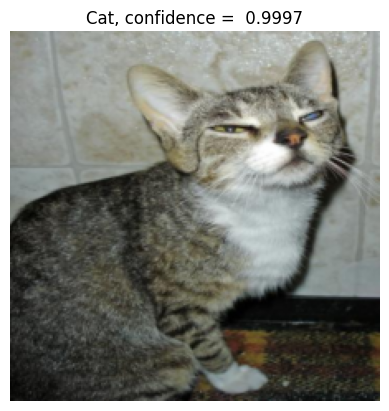

In [ ]:
while True:
    # ищем кошку
    idx = np.random.randint(0, len(train_set))
    if train_set[idx][1] != 0:
        continue
    cat_image = train_set[idx][0]
    break

# Разрешим вычисление градиента по картинке
cat_image.requires_grad = True

pred = model(cat_image[None])
predicted_label = pred.argmax(1).item()
confidence = pred.softmax(1)[0][predicted_label]
if predicted_label == 1:
    plt.title("Dog, confidence = %0.4f" % confidence.item())
else:
    plt.title("Cat, confidence =  %0.4f" % confidence.item())
plt.axis("off")
plt.imshow(cat_image.cpu().detach().numpy().transpose((1, 2, 0)) + 0.5);

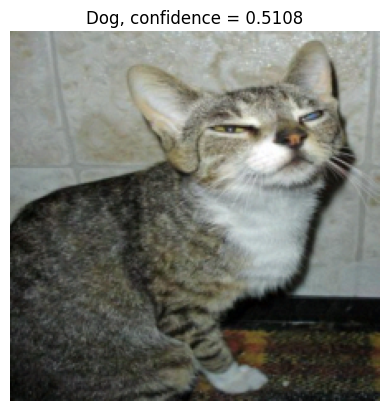

In [ ]:
loss = nn.CrossEntropyLoss()(pred, torch.tensor(0).reshape((1,)))
loss.backward()

eps = 0.007

cat_image_perturbated = fgsm_attack(cat_image, eps, cat_image.grad)
pred = model(cat_image_perturbated[None])
predicted_label = pred.argmax(1).item()
confidence = pred.softmax(1)[0][predicted_label]

plt.axis("off")
if predicted_label == 1:
    plt.title("Dog, confidence = %0.4f" % confidence.item())
else:
    plt.title("Cat, confidence =  %0.4f" % confidence.item())
plt.imshow(cat_image_perturbated.cpu().detach().numpy().transpose((1, 2, 0)) + 0.5);